In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [7]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Formation de la matrice tranposée**

In [8]:
# en transposant, on obtient "matrix_theme_profile"
# où l'on a les thèmes en lignes et les œuvres en colonnes.
# chaque thème est caractérisé par l’ensemble des œuvres dans lesquelles il apparaît.
# deux thèmes sont proches dans cette ACP s’ils ont des profils d’apparition comparables dans les œuvres.

matrix_theme_profile = (
    matrix_all_extended
    .set_index("Works")[the_themes]
    .T
)
matrix_theme_profile.index.name = "Themes"
matrix_theme_profile.columns.name = "Works"

**ACP des thèmes (variances des axes)**

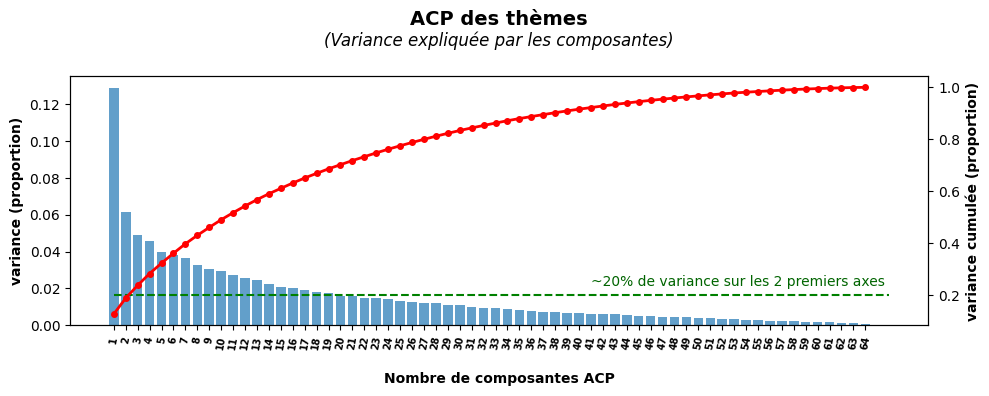

In [9]:
X_tot = matrix_theme_profile.astype(float)

max_comp = min(X_tot.shape[0] - 1, X_tot.shape[1])

pca_tot = PCA(n_components = max_comp)

pca_tot.fit(X_tot)

var = pca_tot.explained_variance_ratio_

fig, ax1 = plt.subplots(figsize=(10, 4))

xs = range(max_comp)
labels_xs=[i+1 for i in list(xs)]
ax1.bar(x=xs, height=var, alpha=0.7, label="variance par axe (%)")
ax1.set_xlabel("\nNombre de composantes ACP", fontweight="bold")
ax1.set_ylabel("variance (proportion)", fontweight="bold")
ax1.set_xticks(xs, labels_xs, fontsize=7, fontweight="bold", rotation=80)

cum_var = np.cumsum(var)

ax2 = ax1.twinx()
ax2.plot(xs, cum_var, color="red", marker="o", ms=4, linewidth=2, label="variance cumulée")
ax2.set_ylabel("variance cumulée (proportion)", fontweight="bold")

ax2.hlines(
    y=0.20,
    xmin=0,
    xmax=65,
    color="green",
    linestyle="--",
    linewidth=1.5,
    zorder=0
)
trans = offset_copy(ax2.transData, fig=fig, x=0, y=5, units='points')

ax2.text(
    40,
    0.20,
    "~20% de variance sur les 2 premiers axes",
    transform=trans,
    rotation=0,
    va="bottom",
    fontsize=10,
    color="darkgreen"
)

fig.tight_layout(rect=[0, 0, 1, 0.85])

titres(fig, ax1,
    t1="ACP des thèmes", y1=37,
    t2="(Variance expliquée par les composantes)", y2=22,
    t3=" ", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_ACP_variances_expliquées.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()

**Variance sur les 2 premières composantes**

In [10]:
var[0] + var[1]

np.float64(0.18987447231665988)

**ACP sur les axes 1 et 2**

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


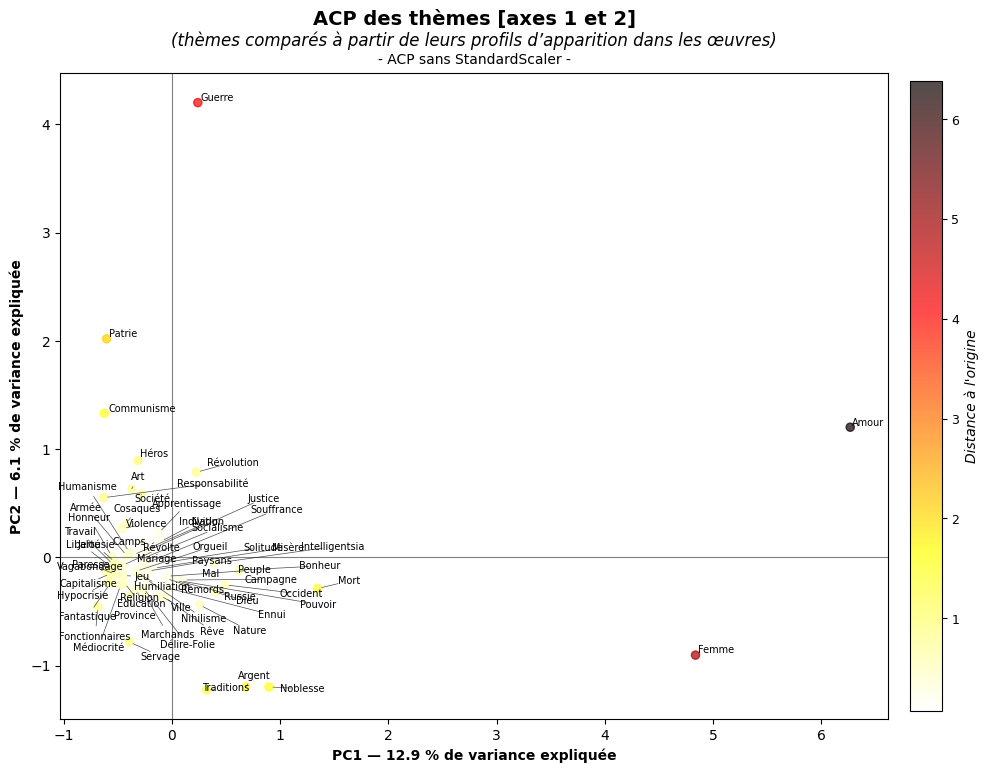

In [11]:
X = matrix_theme_profile.astype(float)

# réaliser la PCA

pca = PCA(n_components=2)

# contient les coordonnées sur les deux axes PCA

row_coords = pca.fit_transform(X)

# Pourcentage de variance expliqué

PC1, PC2 = pca.explained_variance_ratio_

# coordonnées dans le plan ACP

theme_coords = pd.DataFrame(
    row_coords,
    columns=["PC1", "PC2"],
    index=X.index
)

# distance à l'origine : mesure visuelle de contribution/importance sur le plan

theme_coords["dist_origin"] = np.sqrt(
    theme_coords["PC1"]**2 + theme_coords["PC2"]**2
)

import io
import contextlib
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    theme_coords["PC1"],
    theme_coords["PC2"],
    c=theme_coords["dist_origin"],
    cmap="hot_r",
    s=35,
    alpha=0.7,
    zorder=1
)

texts = []

for theme in theme_coords.index:
    texts.append(
        ax.text(
            theme_coords.loc[theme, "PC1"],
            theme_coords.loc[theme, "PC2"],
            theme,
            fontsize=7,
            color="black",
            zorder=3
        )
    )

with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        texts,
        ax=ax,
        x=theme_coords["PC1"],
        y=theme_coords["PC2"],
        expand_text=(1.2, 1.4),
        expand_points=(1.4, 1.6),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5,
            alpha=0.7,
            shrinkA=8,
            shrinkB=3
        )
    )

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)

ax.set_xlabel(f"PC1 — {PC1*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')
ax.set_ylabel(f"PC2 — {PC2*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')

ax.set_aspect("equal")

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.70,     # raccourcit la barre à x % de sa hauteur
    fraction=0.045,  # barre plus mince
    pad=0.025        # rapproche légèrement la barre du graphique
)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Distance à l'origine", fontsize=10, fontstyle="italic")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(fig, ax,
    t1="ACP des thèmes [axes 1 et 2]", y1=35,
    t2="(thèmes comparés à partir de leurs profils d’apparition dans les œuvres)", y2=20,
    t3="- ACP sans StandardScaler -", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_ACP_PC1_PC2.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()

**Identification des thèmes excentrés**

In [12]:
theme_coords["frequence"] = matrix_theme_profile.sum(axis=1)

theme_coords.sort_values("dist_origin", ascending=False).head(9)

,PC1,PC2,dist_origin,frequence
Themes,,,,
Amour,6.266309,1.202615,6.380667,57
Femme,4.836847,-0.902922,4.920403,44
Guerre,0.239033,4.201218,4.208012,25
Patrie,-0.604322,2.019183,2.107678,10
Noblesse,0.895187,-1.196920,1.494650,18
Communisme,-0.624974,1.330452,1.469930,8
Argent,0.681573,-1.197091,1.377523,21
Mort,1.346287,-0.288067,1.376761,22
Traditions,0.321335,-1.223953,1.265432,17


**Oeuvres où apparaissent les 3 thèmes les + excentrés**

In [13]:
themes_extremes = (
    theme_coords
    .sort_values("dist_origin", ascending=False)
    .head(3)
    .index
)

for theme in themes_extremes:
    works = matrix_theme_profile.columns[matrix_theme_profile.loc[theme] == 1].tolist()
    print("\n", theme)
    print("Nombre d'œuvres :", len(works))
    print(works)


 Amour
Nombre d'œuvres : 57
["L'Adolescent", 'Anna Karénine', 'À qui la faute?', 'Bonheur conjugal', 'Boris Godounov', 'Le Brigadier', 'Le Chemin des tourments', "Le Collier d'ambre", 'Le Convive de pierre', 'Crime et Châtiment', 'La Dame au petit chien', 'Dans les forêts', 'Le Démon mesquin', 'Les Démons', "Destin d'un homme", 'Le Docteur Jivago', 'Le Don Paisible', 'Doubrovski', 'Douce', 'Un Eté extraordinaire', "L'Eternel mari", 'Eugène Onéguine', 'La Fille du capitaine', 'Les Frères Karamazov', 'Fumée', 'Guerre et Paix', 'Un Héros de notre temps', "L'Homme ne vit pas seulement de pain", 'Humiliés et Offensés', "L'Idiot", 'Ivanov', 'Une Jeunesse inquiète', 'Le Joueur', 'Kira', 'Lady Macbeth du district de Mtsensk', "Le Malheur d'avoir de l'esprit", 'La Mère', 'Un Mois à la campagne', 'Nid de Gentilshommes', 'Nous autres', 'Les Nuits blanches', "L'Orage", 'La Pauvre Lise', 'Les Pauvres gens', 'Le Pavillon des cancéreux', 'Le Prix des jours', "Propriétaires d'autrefois", 'Le Quarante

**Regarder avec quels thèmes ils co-occurrent le plus**

In [14]:
matrix_co_occurrence = matrix_theme_profile @ matrix_theme_profile.T

cooc_tables = []

for theme in themes_extremes:
    
    s = (
        matrix_co_occurrence
        .loc[theme]
        .drop(theme)                  # enlève la diagonale : Amour-Amour, Femme-Femme, etc.
        .sort_values(ascending=False)
        .head(9)
    )
    
    df = s.reset_index()
    
    df.columns = pd.MultiIndex.from_tuples([
        (theme, "thème associé"),
        (theme, "co-occurrence")
    ])
    
    df.index = range(1, len(df) + 1)
    
    cooc_tables.append(df)

df_cooc_extremes = pd.concat(cooc_tables, axis=1)

df_cooc_extremes.index.name = "Rang"

df_cooc_extremes

Amour                         Femme                \
     thème associé co-occurrence   thème associé co-occurrence   
Rang                                                             
1            Femme            27           Amour            27   
2             Mort            11            Mort             9   
3          Bonheur             9        Noblesse             8   
4           Guerre             8          Argent             8   
5         Noblesse             8      Traditions             7   
6         Occident             7      Révolution             6   
7           Argent             7  Intelligentsia             6   
8             Dieu             6         Bonheur             5   
9           Nature             5            Dieu             5   

              Guerre                
       thème associé co-occurrence  
Rang                                
1             Patrie            10  
2              Amour             8  
3         Communisme             6  
4              Héros             5  
5         Révolution             5  
6     Responsabilité             4  
7              Femme             4  
8                Art             3  
9            Société             3

**ACP sur les axes 3 et 4 (pour ANNEXE)**

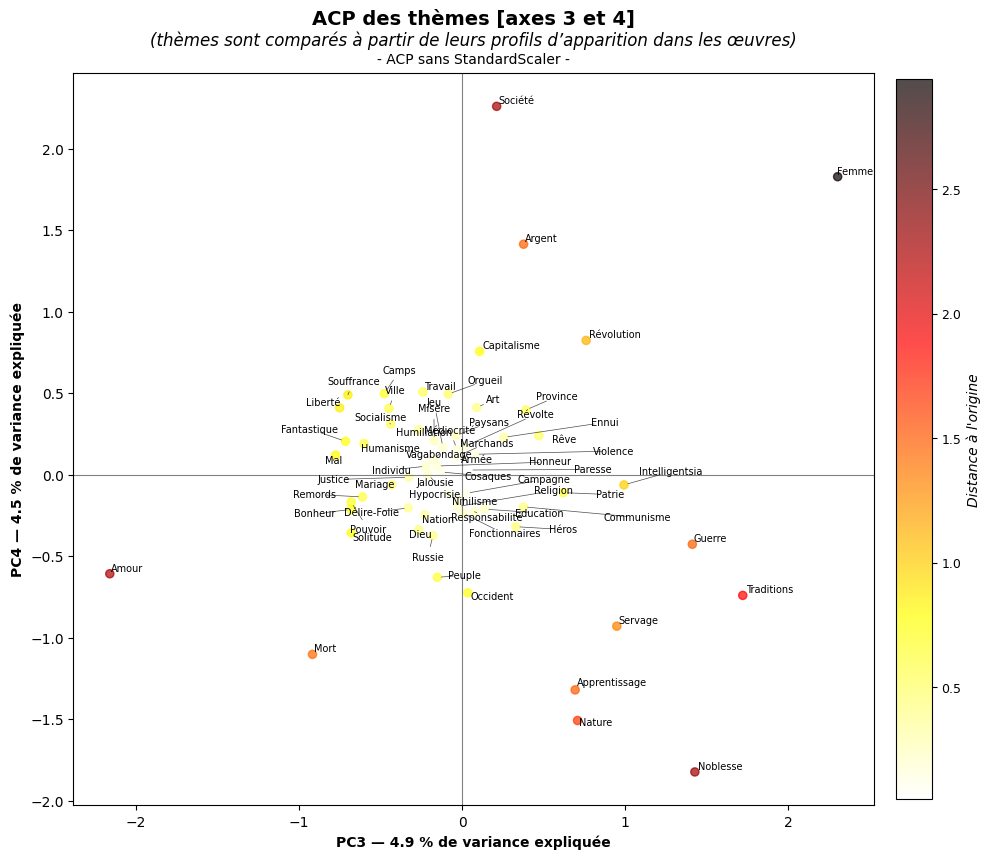

In [15]:
X = matrix_theme_profile.astype(float)

# réaliser la PCA

pca = PCA(n_components=4)

# contient les coordonnées sur les deux axes PCA

row_coords = pca.fit_transform(X)

# Pourcentage de variance expliqué

PC1, PC2, PC3, PC4 = pca.explained_variance_ratio_

# coordonnées dans le plan ACP

theme_coords = pd.DataFrame(
    row_coords,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=X.index
)

# distance à l'origine : mesure visuelle de contribution/importance sur le plan

theme_coords["dist_origin"] = np.sqrt(
    theme_coords["PC3"]**2 + theme_coords["PC4"]**2
)

import io
import contextlib
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(
    theme_coords["PC3"],
    theme_coords["PC4"],
    c=theme_coords["dist_origin"],
    cmap="hot_r",
    s=35,
    alpha=0.7,
    zorder=1
)

texts = []

for theme in theme_coords.index:
    texts.append(
        ax.text(
            theme_coords.loc[theme, "PC3"],
            theme_coords.loc[theme, "PC4"],
            theme,
            fontsize=7,
            color="black",
            zorder=3
        )
    )

with contextlib.redirect_stdout(io.StringIO()):
    adjust_text(
        texts,
        ax=ax,
        x=theme_coords["PC3"],
        y=theme_coords["PC4"],
        expand_text=(1.2, 1.4),
        expand_points=(1.4, 1.6),
        force_text=(0.4, 0.6),
        force_points=(0.3, 0.5),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.5,
            alpha=0.7,
            shrinkA=8,
            shrinkB=3
        )
    )

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)

ax.set_xlabel(f"PC3 — {PC3*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')
ax.set_ylabel(f"PC4 — {PC4*100:.1f} % de variance expliquée", fontsize=10, fontweight='bold')

ax.set_aspect("equal")

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.80,     # raccourcit la barre à x % de sa hauteur
    fraction=0.045,  # barre plus mince
    pad=0.025        # rapproche légèrement la barre du graphique
)
cbar.ax.tick_params(labelsize=9)
cbar.set_label("Distance à l'origine", fontsize=10, fontstyle="italic")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(fig, ax,
    t1="ACP des thèmes [axes 3 et 4]", y1=35,
    t2="(thèmes sont comparés à partir de leurs profils d’apparition dans les œuvres)", y2=20,
    t3="- ACP sans StandardScaler -", y3=7
)

fig.savefig(IMG_DIR / "thèmes_ACP_PC3_PC4.png", 
            dpi=300,
            bbox_inches="tight")

plt.show()